In [15]:
import os
PATH     = "/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/data"
#PATH     ="C:/Users/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/data"
filename = "JICAMARCA_OCSD.csv"
file_dir = os.path.join(PATH,filename)
print(file_dir)

/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/data/JICAMARCA_OCSD.csv


In [17]:
import pandas as pd
df_raw  = pd.read_csv(file_dir)
df_raw.head()

,ID_Satelite,Tiempo,S4,Azimuth,Elevacion
0,1,2025-01-22 17:31:00,0.077,154.0,53.0
1,1,2025-01-22 17:32:00,0.054,153.0,54.0
2,1,2025-01-22 17:33:00,0.043,153.0,54.0
3,1,2025-01-22 17:34:00,0.062,152.0,54.0
4,1,2025-01-22 17:35:00,0.044,151.0,54.0


In [41]:
s4_parm  = pd.read_csv(file_dir)

s4_param =  s4_param.sort_values(by="Tiempo")
s4_param.head(40)

,ID_Satelite,Tiempo,S4,Azimuth,Elevacion
1750039,20,2025-01-01 00:01:00,0.112,212.0,34.0
4626668,59,2025-01-01 00:01:00,0.066,312.0,25.0
7497041,131,2025-01-01 00:01:00,0.000,284.0,42.0
4978672,73,2025-01-01 00:01:00,0.061,186.0,37.0
5475612,78,2025-01-01 00:01:00,0.059,239.0,18.0
476875,6,2025-01-01 00:01:00,0.000,313.0,47.0
3469544,45,2025-01-01 00:01:00,0.284,196.0,19.0
4876833,72,2025-01-01 00:01:00,0.028,14.0,39.0
8131467,135,2025-01-01 00:01:00,0.011,280.0,34.0
3384982,44,2025-01-01 00:01:00,0.123,142.0,31.0


In [43]:
df_raw['Tiempo'] = pd.to_datetime(df_raw['Tiempo'])

# ==============================================================================
# PIPELINE DE LIMPIEZA
# ==============================================================================

def procesar_data_tesis(df, angulo_corte=30.0):
    print(f"📊 Datos Crudos: {len(df)} registros")
    
    # PASO A: Análisis del 'Peor Caso' SIN filtro (Lo que NO debes hacer)
    max_s4_sucio = df.groupby('Tiempo')['S4'].max()
    print(f"⚠️ Max S4 (Sin Filtro) a las 00:01: {max_s4_sucio.iloc[0]} (FALSO POSITIVO)")
    
    # PASO B: Filtro de Elevación (Lo CORRECTO)
    # Eliminamos todo lo que esté debajo de 30 grados
    df_clean = df[df['Elevacion'] >= angulo_corte].copy()
    print(f"🧹 Datos después del filtro >{angulo_corte}°: {len(df_clean)} registros")
    
    # PASO C: Unificación (Peor Caso Real)
    # Buscamos el ID del satélite con el peor S4 valido
    idx_maximos = df_clean.groupby('Tiempo')['S4'].idxmax()
    df_unificado = df_clean.loc[idx_maximos].set_index('Tiempo').sort_index()
    
    # PASO D: Relleno de continuidad (1 min)
    df_final = df_unificado.asfreq('1min')
    df_final['S4'] = df_final['S4'].fillna(0.0) # Si no hay satélites, es calma
    
    # Rellenar elevación (solo para referencia)
    df_final['Elevacion'] = df_final['Elevacion'].interpolate().fillna(0)
    
    print(f"✅ Max S4 (Con Filtro) a las 00:01: {df_final['S4'].iloc[0]} (REAL)")
    
    return df_final

# Ejecutar
df_listo_para_lstm = procesar_data_tesis(df_raw, angulo_corte=30.0)
print("\n--- DATAFRAME FINAL PARA LSTM ---")
print(df_listo_para_lstm.head())

📊 Datos Crudos: 8625704 registros
⚠️ Max S4 (Sin Filtro) a las 00:01: 0.413 (FALSO POSITIVO)
🧹 Datos después del filtro >30.0°: 4948415 registros
✅ Max S4 (Con Filtro) a las 00:01: 0.144 (REAL)

--- DATAFRAME FINAL PARA LSTM ---
                     ID_Satelite     S4  Azimuth  Elevacion
Tiempo                                                     
2025-01-01 00:01:00          7.0  0.144    157.0       36.0
2025-01-01 00:02:00         44.0  0.186    142.0       31.0
2025-01-01 00:03:00         44.0  0.172    141.0       31.0
2025-01-01 00:04:00          7.0  0.133    157.0       35.0
2025-01-01 00:05:00          7.0  0.129    157.0       35.0


/tmp/ipykernel_2677776/2607968385.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_activos['SatID_Str'] = df_activos['ID_Satelite'].astype(int).astype(str)
/tmp/ipykernel_2677776/2607968385.py:71: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


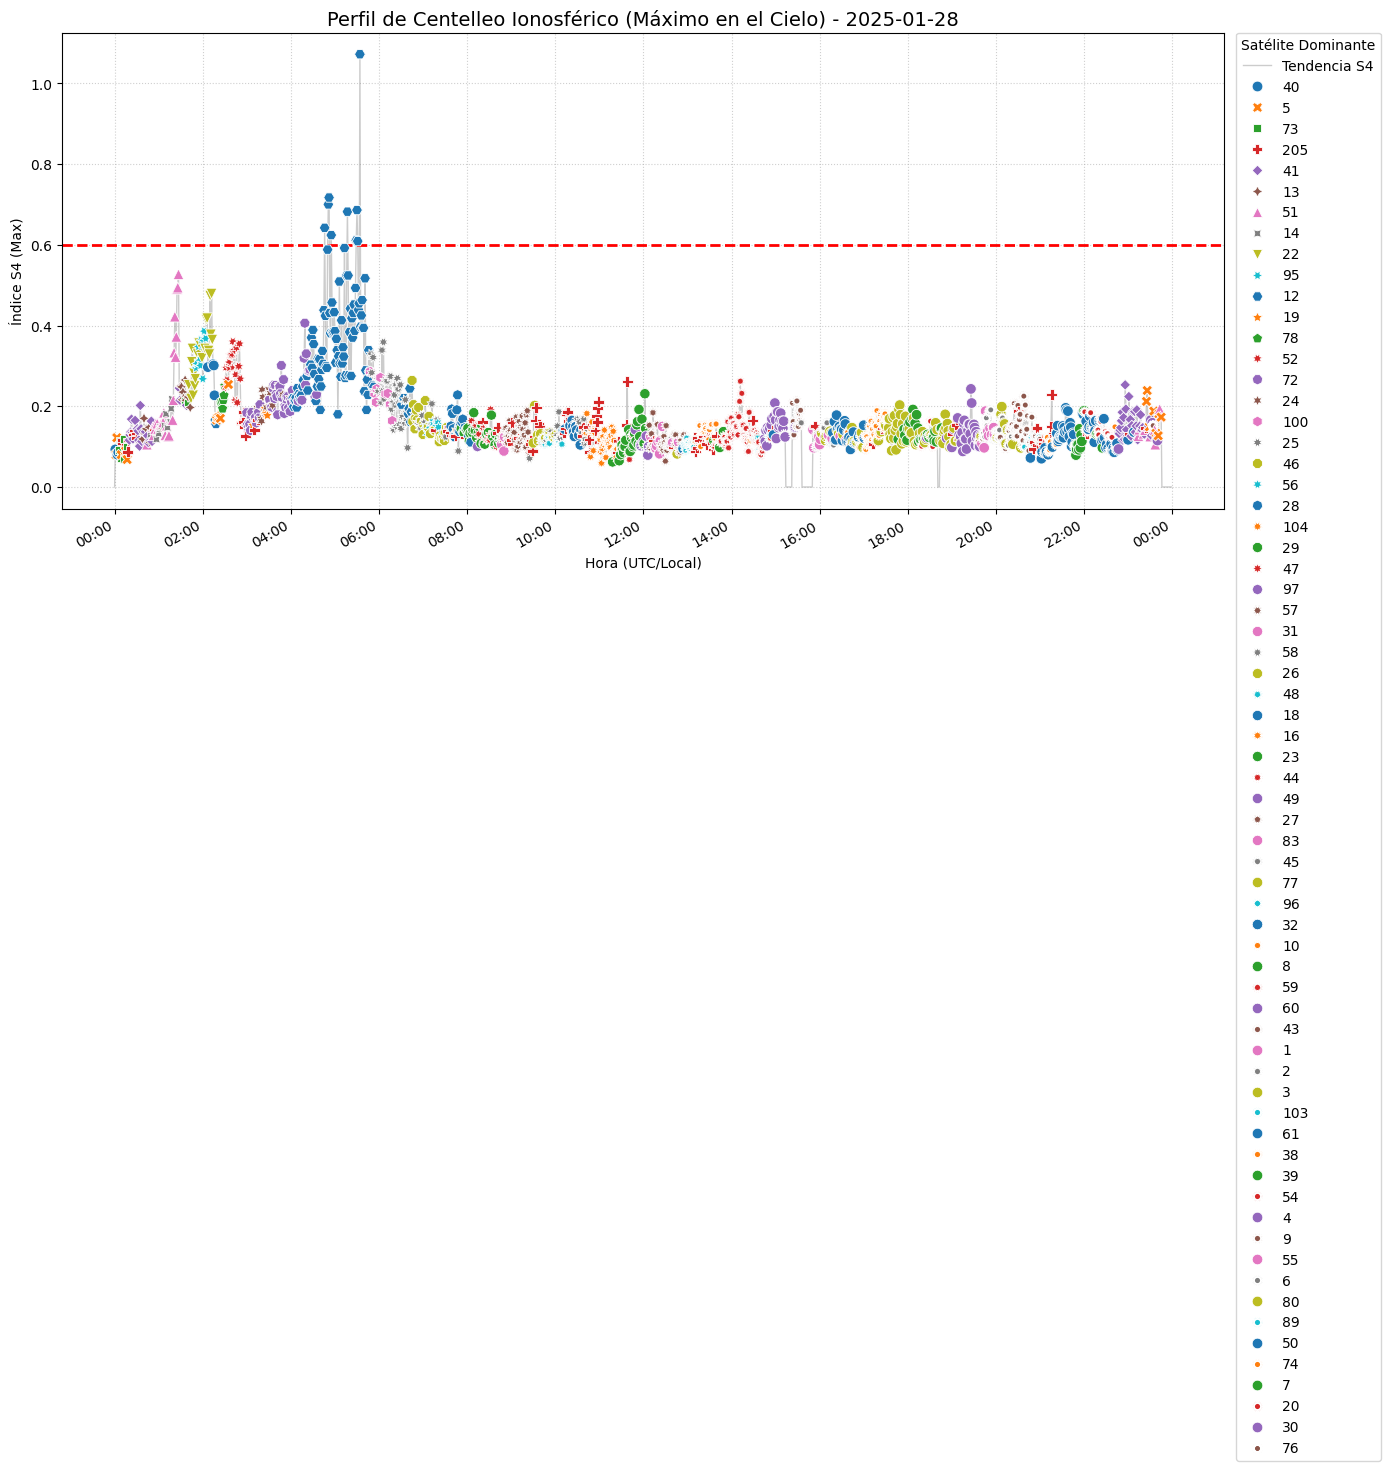

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

def graficar_perfil_diario_s4(df, fecha_str, umbral_s4=0.6):
    """
    Grafica la serie unificada de S4, coloreando los puntos según el Satélite ID
    que reportó el máximo en ese minuto.
    
    Args:
        df: DataFrame UNIFICADO (Index=Tiempo, Cols=[ID_Satelite, S4, ...])
        fecha_str: 'YYYY-MM-DD'
    """
    # 1. Filtro por Fecha
    # Aseguramos que el índice sea datetime
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
        
    df_dia = df[df.index.strftime('%Y-%m-%d') == fecha_str].copy()
    
    if df_dia.empty:
        print(f"⚠️ No hay datos para la fecha {fecha_str}")
        return

    # 2. Configuración del Gráfico
    plt.figure(figsize=(15, 7))
    
    # A. GRÁFICA DE LÍNEA (Tendencia Continua)
    # Pinta una línea gris suave para mostrar la continuidad de la señal
    plt.plot(df_dia.index, df_dia['S4'], color='gray', alpha=0.4, linewidth=1, label='Tendencia S4')
    
    # B. GRÁFICA DE DISPERSIÓN (Puntos Coloreados por ID)
    # Usamos Seaborn porque maneja muy bien las categorías de colores
    # Filtramos solo donde S4 > 0 para no llenar el gráfico de puntos en el suelo (calma)
    df_activos = df_dia[df_dia['S4'] > 0.05] # Solo mostramos actividad relevante visualmente
    
    if not df_activos.empty:
        # Convertir ID a string para que sea categórico discreto en la leyenda
        df_activos['SatID_Str'] = df_activos['ID_Satelite'].astype(int).astype(str)
        
        scatter = sns.scatterplot(
            data=df_activos,
            x=df_activos.index,
            y='S4',
            hue='SatID_Str',     # El color depende del ID
            style='SatID_Str',   # La forma también (opcional, ayuda si hay muchos colores)
            s=60,                # Tamaño del punto
            palette='tab10',     # Paleta de colores distintivos
            zorder=10            # Que queden encima de la línea gris
        )
        
        # Mover la leyenda fuera del gráfico
        plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, title="Satélite Dominante")
    
    # 3. Decoración Crítica
    # Línea de Umbral (Tormenta)
    plt.axhline(y=umbral_s4, color='red', linestyle='--', linewidth=2, label='Umbral Crítico')
    
    # Títulos y Ejes
    plt.title(f"Perfil de Centelleo Ionosférico (Máximo en el Cielo) - {fecha_str}", fontsize=14)
    plt.ylabel("Índice S4 (Max)")
    plt.xlabel("Hora (UTC/Local)")
    
    # Formato de Hora
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=2))
    plt.gcf().autofmt_xdate()
    
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

# --- EJEMPLO DE USO ---
# Asumiendo que 'df_final_series' es tu dataframe unificado
graficar_perfil_diario_s4(df_listo_para_lstm, '2025-01-28')

📡 Filtro de Elevación (>30.0°):
   - Registros antes: 8625704
   - Registros después: 4797115
   - Eliminados: 3828589 (Ruido potencial)
⚡ Detección de Outliers (Ratio=3.0):
   - Anomalías detectadas: 15431
📅 Fecha: 2025-01-28 | Satélites visibles: 79


/tmp/ipykernel_2677776/1808945852.py:76: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


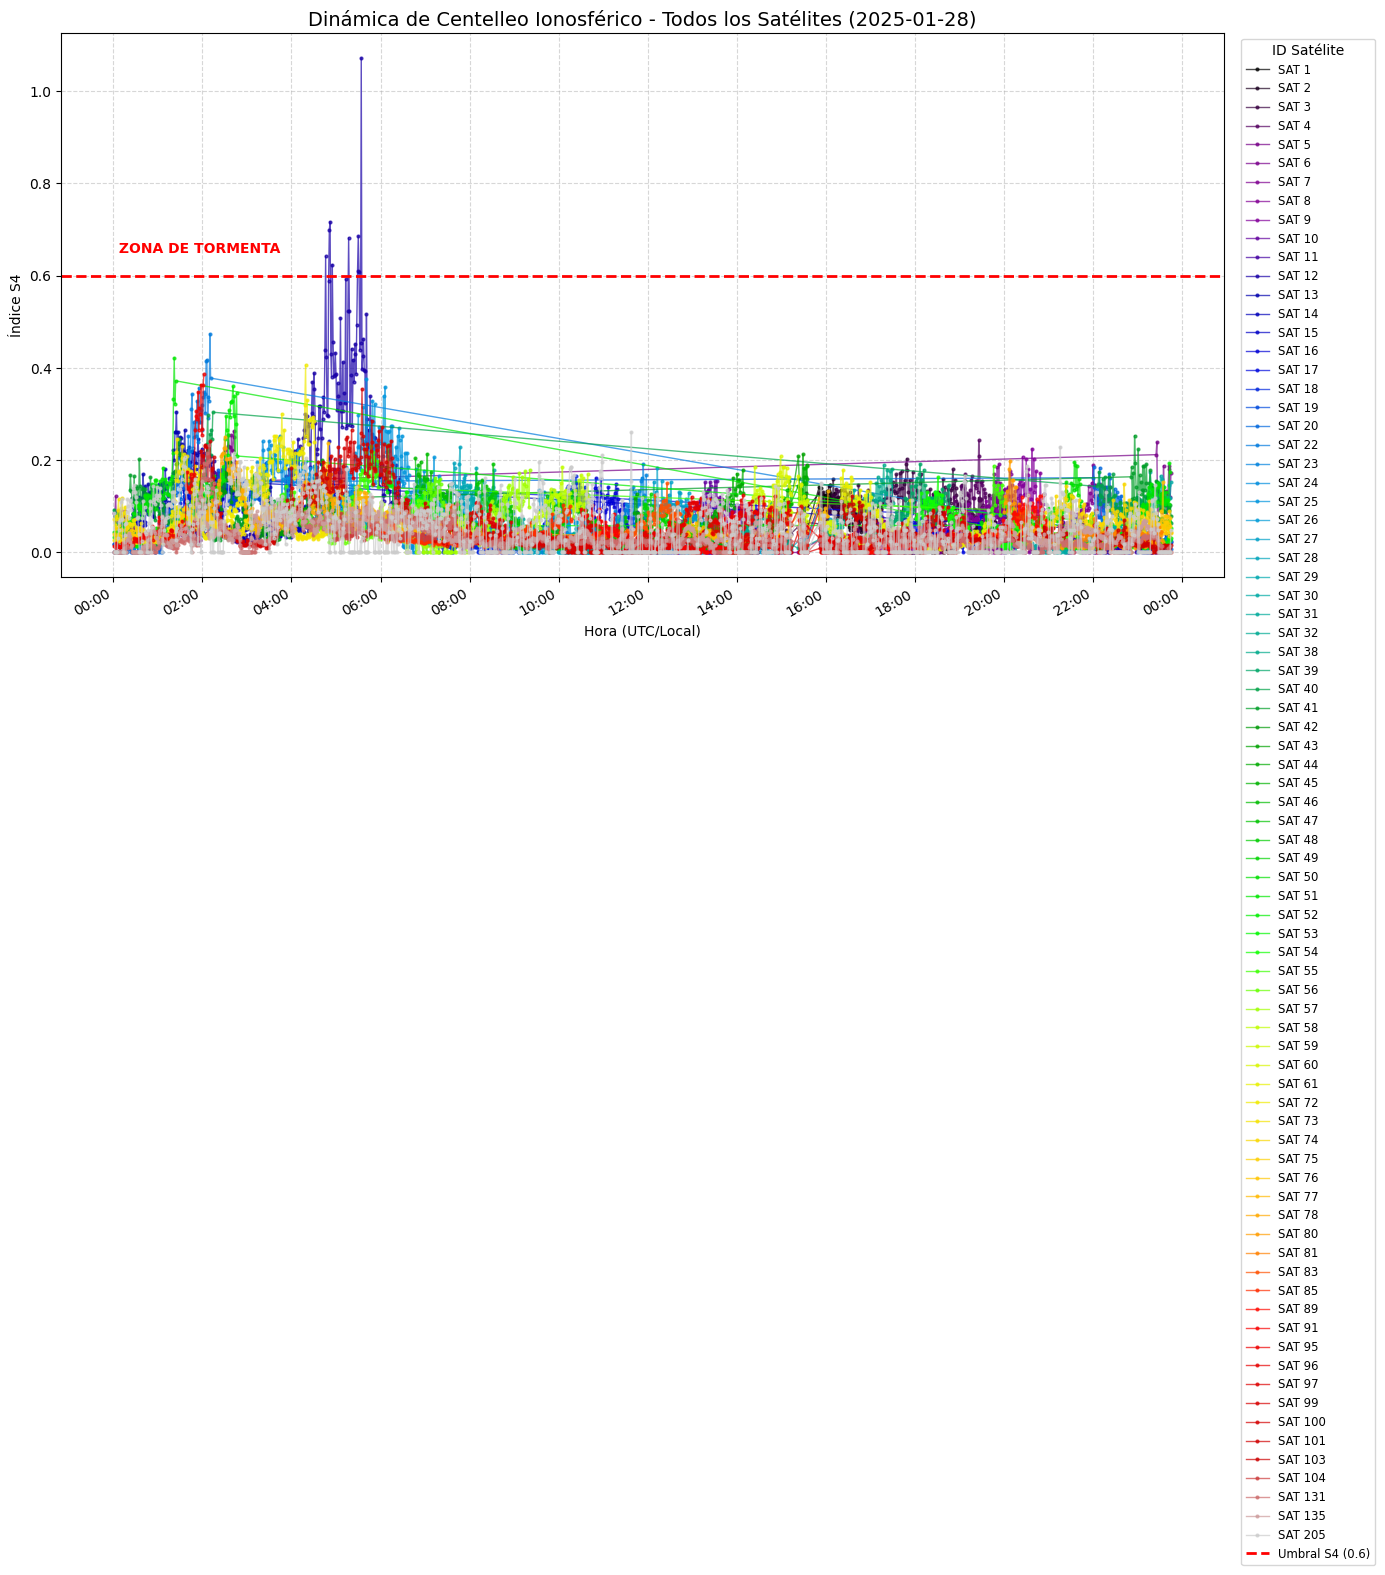

In [49]:
# =============================================================================
# EJECUCIÓN DEL PIPELINE
# =============================================================================
# Suponiendo que 'df_raw' es tu dataframe original con columnas: 
# ['ID_Satelite', 'Tiempo', 'S4', 'Elevacion', ...]

# 1. Filtro de Ángulo (>30°)
df_elev = filtrar_por_elevacion(df_raw, umbral_grados=30.0)

# 2. Detección y Eliminación de Spikes
# threshold_ratio=0.5 o 1.0 puede ser muy estricto, 2.0 o 3.0 es usual para "spikes" fuertes.
df_marked = marcar_outliers_satelitales(df_elev, threshold_ratio=3.0) 
df_clean_satellites = eliminar_outliers(df_marked)

graficar_satelites_por_dia(df_clean_satellites, '2025-01-28')